## import required Libraries

In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## load dataset into the model and show main informations

In [2]:
df = pd.read_csv("/content/Training_Liver_Disease_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Training_Liver_Disease_Dataset.csv'

In [ ]:
df.head()

In [ ]:
df.shape

(30000, 33)

In [ ]:
numerical = ['Age', 'BMI', 'Waist_Circumference', 'Sleep_Hours', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'GGT', 'Triglycerides', 'INR']
binary = ['Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes', 'Comorb_Hypertension', 'Comorb_Genetic_History']
categorical = ['Gender', 'Occupation', 'Obesity_Class', 'Diet_Quality', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Consumption', 'Medication_History', 'Source']

In [ ]:
target = "Liver_Disease_Class"

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     30000 non-null  int64  
 1   Gender                  30000 non-null  object 
 2   Occupation              30000 non-null  object 
 3   BMI                     30000 non-null  float64
 4   Obesity_Class           30000 non-null  object 
 5   Waist_Circumference     30000 non-null  float64
 6   Diet_Quality            30000 non-null  object 
 7   Physical_Activity       30000 non-null  object 
 8   Sleep_Hours             30000 non-null  float64
 9   Smoking_Status          30000 non-null  object 
 10  Alcohol_Consumption     22522 non-null  object 
 11  Sym_Fatigue             30000 non-null  int64  
 12  Sym_Jaundice            30000 non-null  int64  
 13  Sym_Abdominal_Pain      30000 non-null  int64  
 14  Sym_Itching             30000 non-null

In [ ]:
df.notnull().sum()

,0
Age,30000
Gender,30000
Occupation,30000
BMI,30000
Obesity_Class,30000
Waist_Circumference,30000
Diet_Quality,30000
Physical_Activity,30000
Sleep_Hours,30000
Smoking_Status,30000


In [ ]:
# Missing data percentage
missing = df.isnull().mean().sort_values(ascending=False)
print(missing)

Alcohol_Consumption       0.249267
Medication_History        0.200600
Age                       0.000000
BMI                       0.000000
Gender                    0.000000
Waist_Circumference       0.000000
Diet_Quality              0.000000
Physical_Activity         0.000000
Occupation                0.000000
Sleep_Hours               0.000000
Smoking_Status            0.000000
Sym_Fatigue               0.000000
Sym_Jaundice              0.000000
Sym_Abdominal_Pain        0.000000
Sym_Itching               0.000000
Sym_Ascites               0.000000
Obesity_Class             0.000000
Sym_Dark_Urine            0.000000
Sym_Weight_Loss           0.000000
Comorb_Hypertension       0.000000
Comorb_Diabetes           0.000000
ALT                       0.000000
AST                       0.000000
Bilirubin                 0.000000
Comorb_Genetic_History    0.000000
Albumin                   0.000000
Platelets                 0.000000
GGT                       0.000000
Alk_Phosphatase     

### as per dataset review we found two Categorical columns with NULL values

Medication_History Null values QTY = 20%
Alcohol_Consumption Null Values Qty = 25%
which is high QTY and not recommended to drop the rows with NULL values.
Recommended to use Missing Values imputation techniques (we will use Mode imputation)

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
df["Alcohol_Consumption"] = imputer.fit_transform(df[["Alcohol_Consumption"]]).ravel()
df["Medication_History"] = imputer.fit_transform(df[["Medication_History"]]).ravel()

In [ ]:
df.notnull().sum()

,0
Age,30000
Gender,30000
Occupation,30000
BMI,30000
Obesity_Class,30000
Waist_Circumference,30000
Diet_Quality,30000
Physical_Activity,30000
Sleep_Hours,30000
Smoking_Status,30000


### Detect Outlier

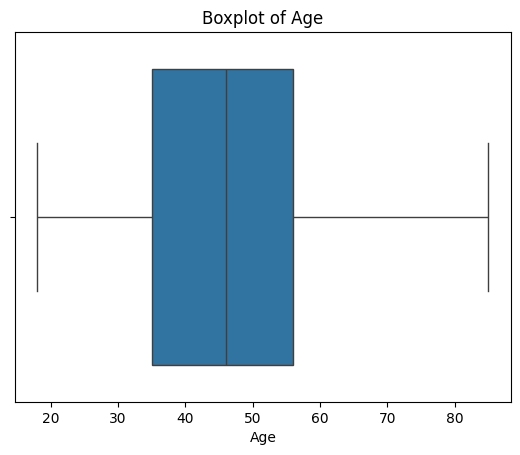

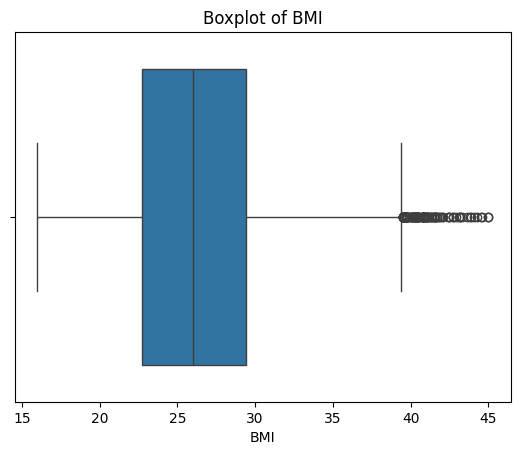

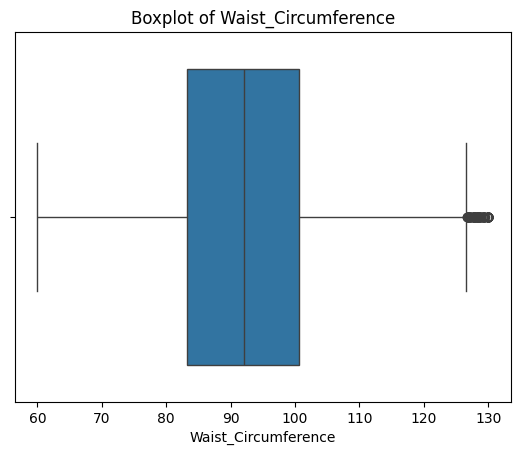

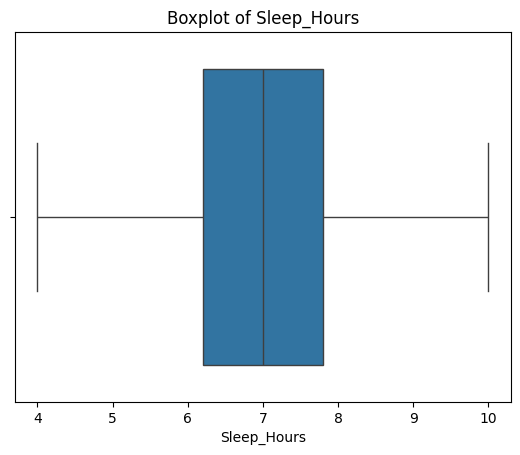

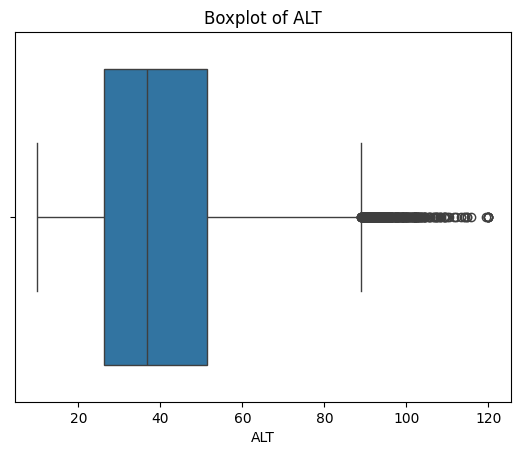

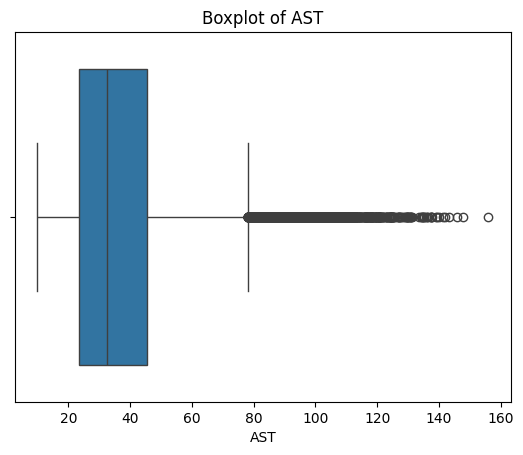

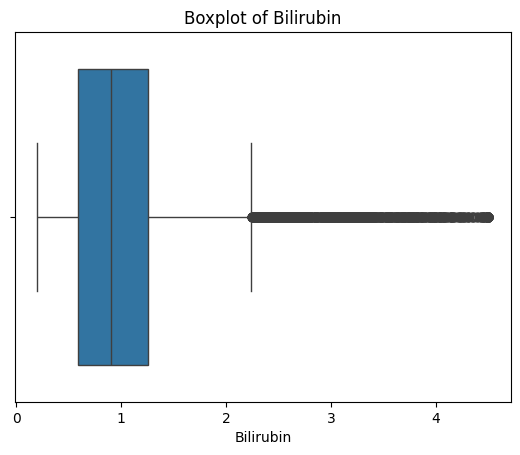

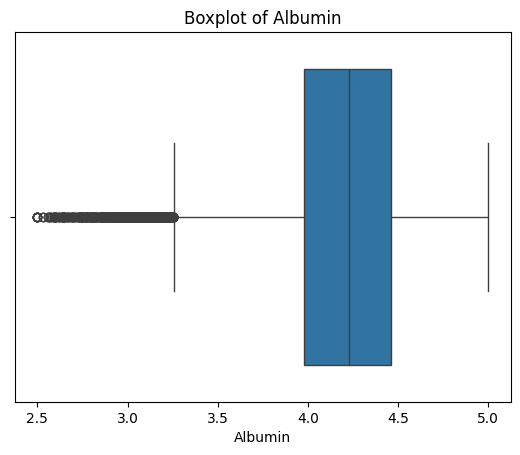

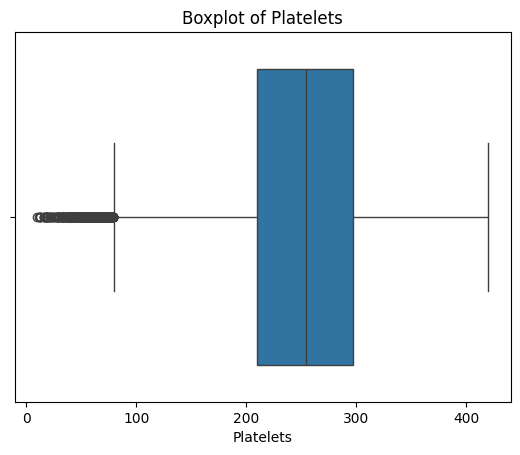

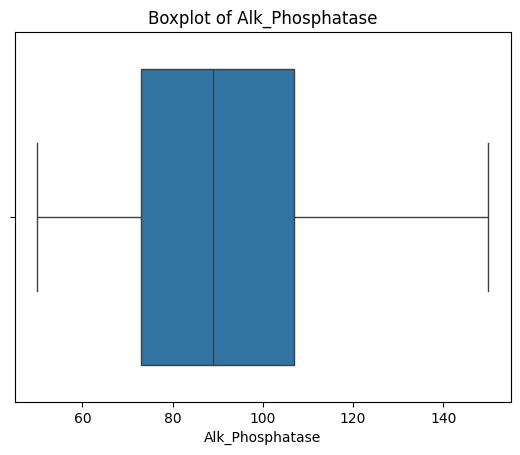

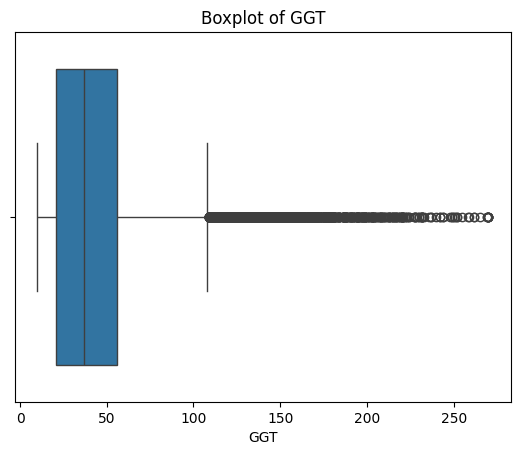

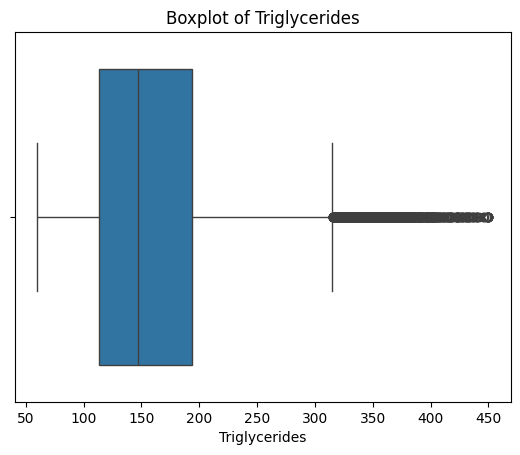

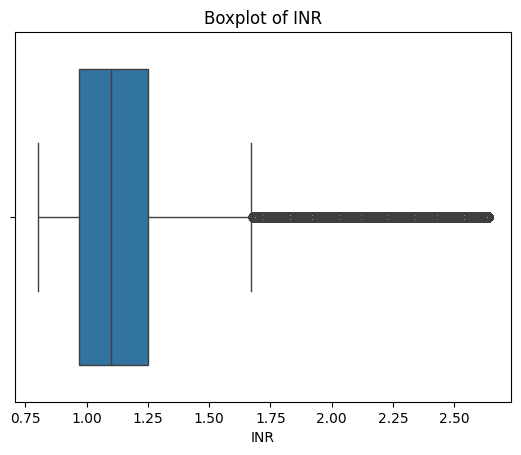

In [ ]:
for col in numerical:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
def detect_outliers_summary(data, features):
    outlier_list = []

    for col in features:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

        outlier_list.append({
            'Feature': col,
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2),
            'Outlier_Count': len(outliers),
            'Percentage': f"{(len(outliers) / len(data)) * 100:.2f}%"
        })

    return pd.DataFrame(outlier_list)

# 3. Generate the summary report
summary = detect_outliers_summary(df, numerical)
print(summary.sort_values(by='Outlier_Count', ascending=False))

                Feature  Lower_Bound  Upper_Bound  Outlier_Count Percentage
12                  INR         0.55         1.67           2633      8.78%
5                   AST        -9.16        78.07           1677      5.59%
6             Bilirubin        -0.40         2.24           1526      5.09%
10                  GGT       -31.50       108.50           1468      4.89%
11        Triglycerides        -8.50       315.50           1144      3.81%
7               Albumin         3.26         5.18            993      3.31%
4                   ALT       -11.21        88.95            325      1.08%
8             Platelets        79.50       427.50            285      0.95%
2   Waist_Circumference        57.35       126.55            116      0.39%
1                   BMI        12.65        39.45            112      0.37%
0                   Age         3.50        87.50              0      0.00%
3           Sleep_Hours         3.80        10.20              0      0.00%
9       Alk_

In [ ]:
def handle_outliers(data, features):
    df_clean = data.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = np.where(df_clean[col] < lower, lower, np.where(df_clean[col] > upper, upper, df_clean[col]))
    return df_clean

df_final = handle_outliers(df, numerical)

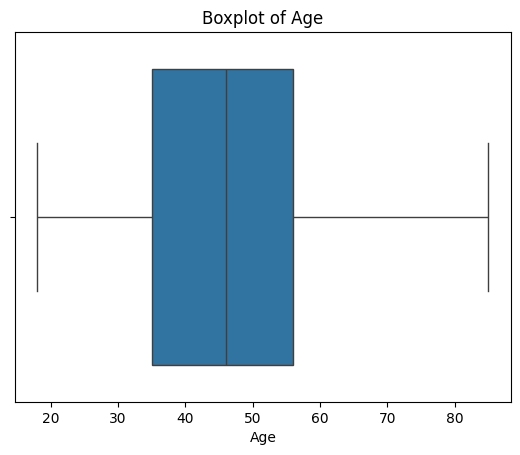

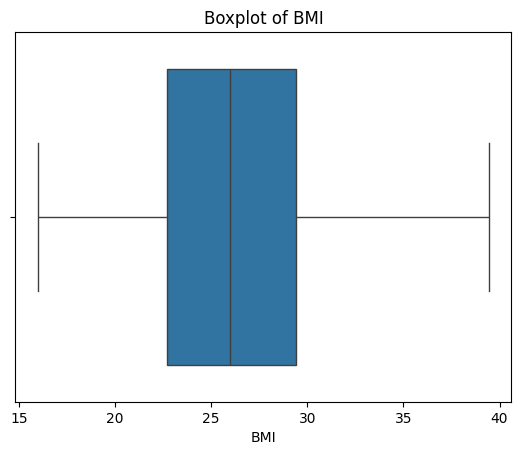

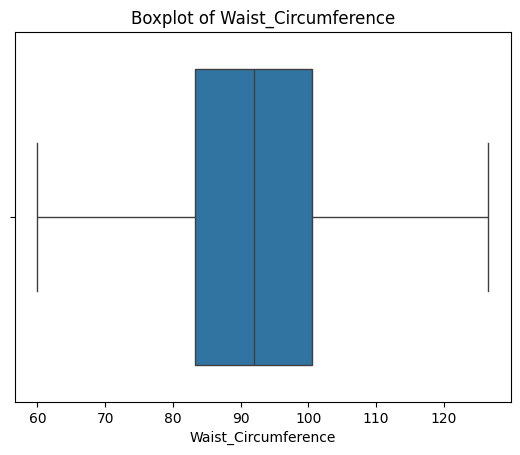

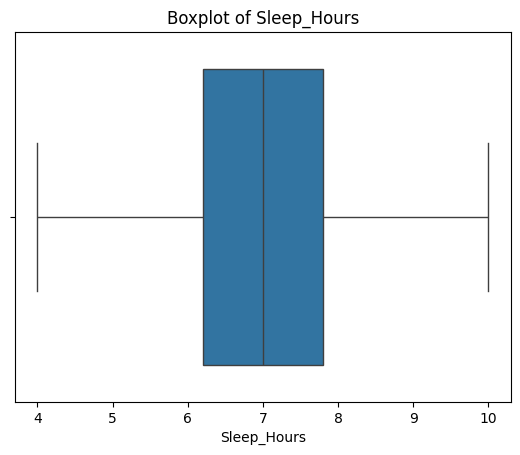

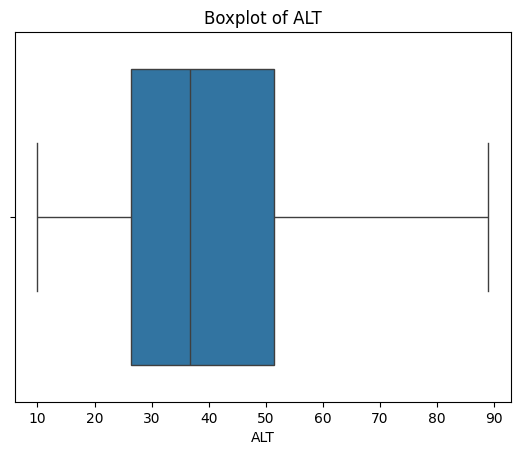

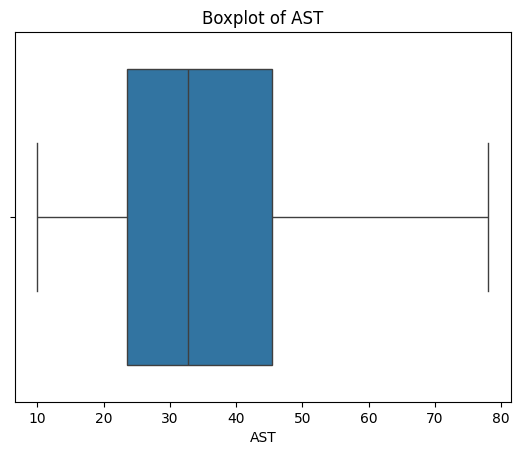

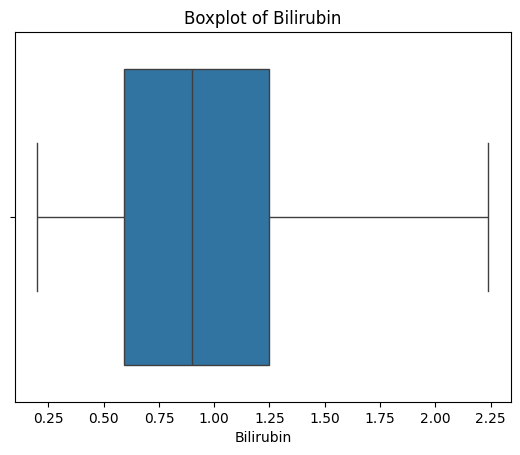

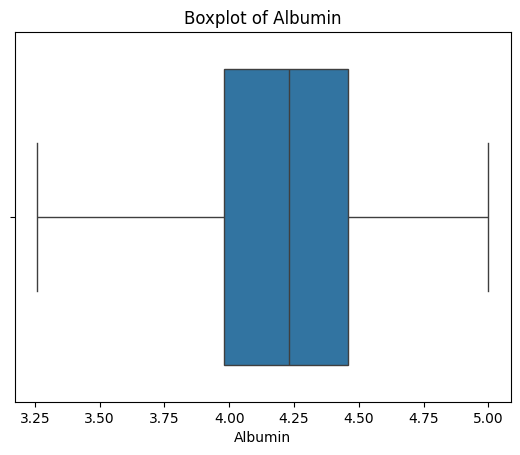

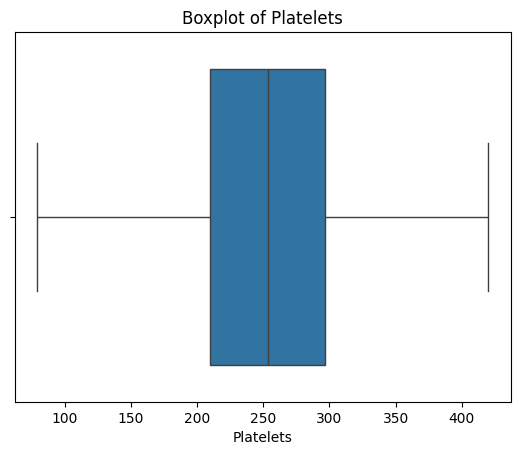

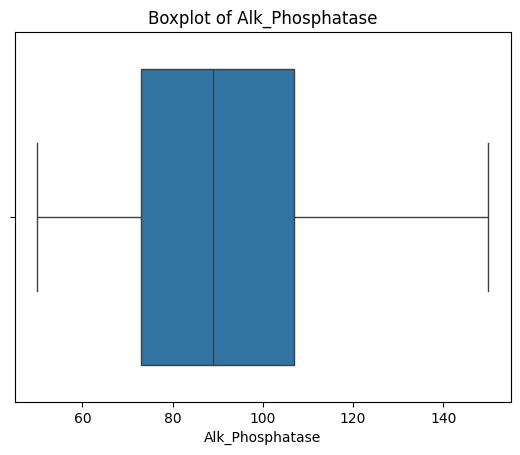

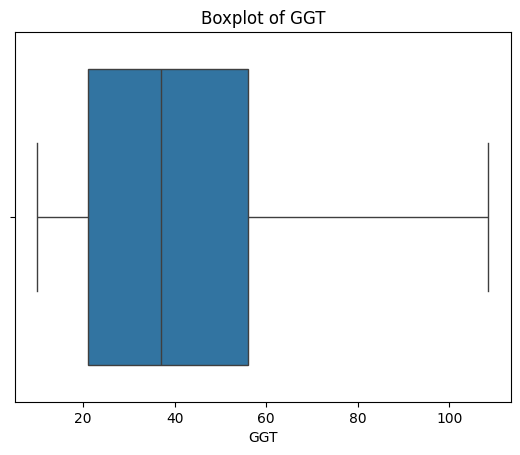

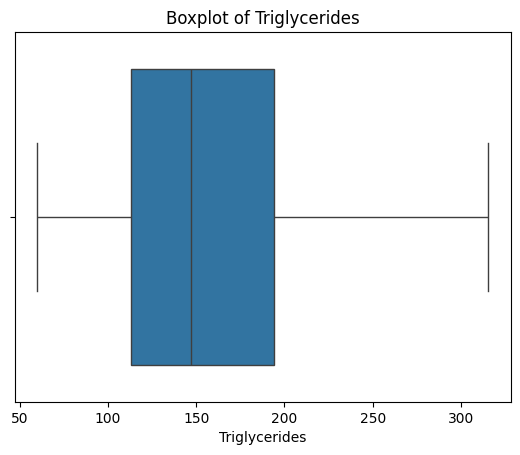

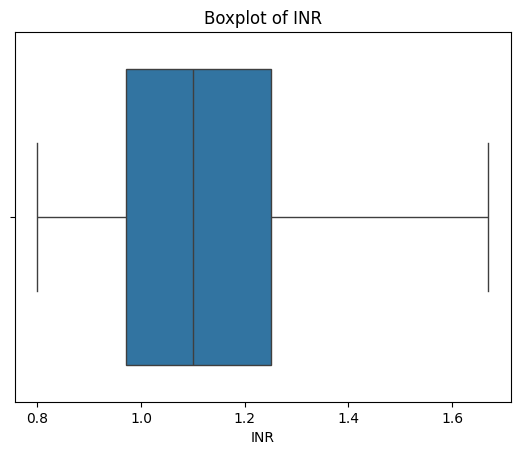

In [ ]:
for col in numerical:
    plt.figure()
    sns.boxplot(x=df_final[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
summary = detect_outliers_summary(df_final, numerical)
print(summary.sort_values(by='Outlier_Count', ascending=False))

                Feature  Lower_Bound  Upper_Bound  Outlier_Count Percentage
0                   Age         3.50        87.50              0      0.00%
1                   BMI        12.65        39.45              0      0.00%
2   Waist_Circumference        57.35       126.55              0      0.00%
3           Sleep_Hours         3.80        10.20              0      0.00%
4                   ALT       -11.21        88.95              0      0.00%
5                   AST        -9.16        78.07              0      0.00%
6             Bilirubin        -0.40         2.24              0      0.00%
7               Albumin         3.26         5.18              0      0.00%
8             Platelets        79.50       427.50              0      0.00%
9       Alk_Phosphatase        22.00       158.00              0      0.00%
10                  GGT       -31.50       108.50              0      0.00%
11        Triglycerides        -8.50       315.50              0      0.00%
12          

### After finalize missing values in dataset, Next we will check the unbalanced in dataset

In [ ]:
df[target].value_counts()

,count
Liver_Disease_Class,
Healthy Liver,13500
Fatty Liver Disease (NAFLD),9000
Alcoholic Liver Disease,3000
General Liver Disease Severity,2400
Liver Cirrhosis Risk,2100


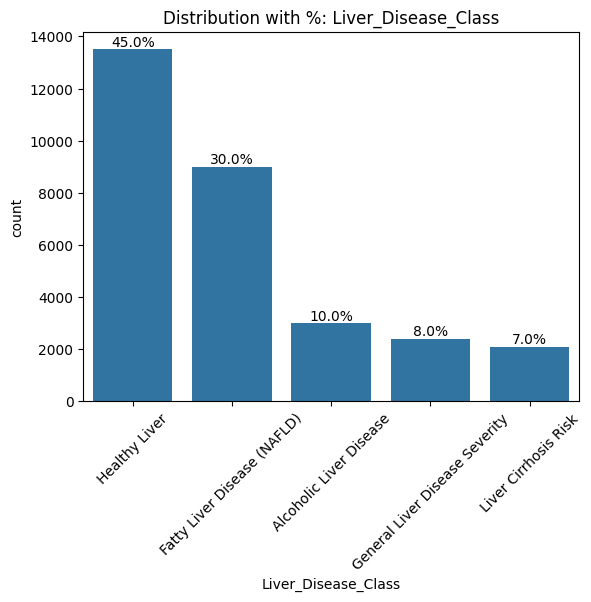

In [ ]:
for col in [target]:
    plt.figure()
    ax = sns.countplot(x=df[col])

    total = len(df[col])
    for p in ax.patches:
        percentage = f"{100 * p.get_height()/total:.1f}%"
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.title(f"Distribution with %: {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
le = LabelEncoder()
df['Liver_Disease_Class'] = le.fit_transform(df['Liver_Disease_Class'])

In [ ]:
for col in categorical:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,62,0,2,29.5,4,89.6,2,3,6.6,1,...,0.69,3.78,190,79,10,155,0.80,3,3,3
1,39,0,1,26.7,4,101.9,2,1,7.0,0,...,1.07,4.38,196,143,13,276,1.14,0,2,1
2,45,1,7,25.5,4,74.5,2,1,6.7,1,...,2.55,3.64,311,84,143,145,1.10,3,4,0
3,67,1,5,30.8,1,98.2,0,3,8.5,0,...,1.89,3.58,307,92,30,91,1.20,1,4,0
4,18,0,1,27.2,4,96.9,0,3,7.4,1,...,0.73,4.63,374,73,10,162,1.20,1,7,3


In [ ]:
# 1. Prepare your data
# Ensure your features (X) and target (y) are separated
X = df.drop('Liver_Disease_Class', axis=1)
y = df['Liver_Disease_Class']


# 2. Apply SMOTE
# This will synthesize new rows for the minority classes
# so they all match the 'Healthy Liver' count (13,500)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After Oversampling:", Counter(y_resampled))

# 3. Create a new balanced DataFrame if needed
balanced_df = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['Liver_Disease_Class'])], axis=1)

After Oversampling: Counter({3: 13500, 1: 13500, 0: 13500, 2: 13500, 4: 13500})


In [ ]:
balanced_df[target].value_counts()

,count
Liver_Disease_Class,
3,13500
1,13500
0,13500
2,13500
4,13500


In [ ]:
balanced_df.shape

(67500, 33)

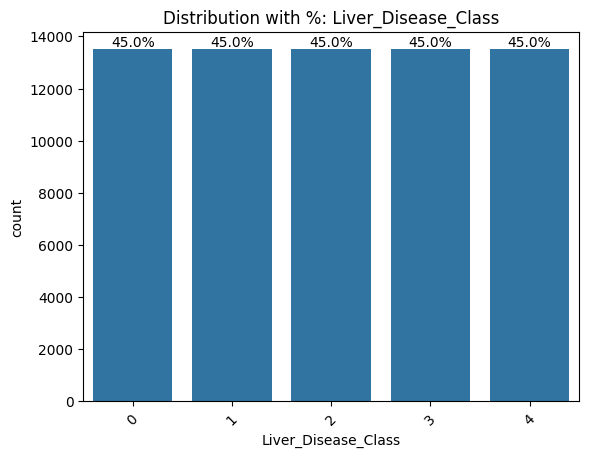

In [ ]:
for col in [target]:
    plt.figure()
    ax = sns.countplot(x=balanced_df[col])

    total = len(df[col])
    for p in ax.patches:
        percentage = f"{100 * p.get_height()/total:.1f}%"
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.title(f"Distribution with %: {col}")
    plt.xticks(rotation=45)
    plt.show()

### Standarization and Normalization of Data

In [ ]:
X = balanced_df.drop('Liver_Disease_Class', axis=1)
y = balanced_df['Liver_Disease_Class']

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

### KNN Model

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(X_scaled , y , test_size = 0.2 , random_state = 42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(x_train , y_train)

KNeighborsClassifier()

In [ ]:
pred = knn.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [ ]:
accuracy_score(y_test , pred)

0.8928148148148148

In [ ]:
import joblib

In [ ]:
joblib.dump(knn, "KNN_liver_model.pkl")

print("\nModel saved as KNN_liver_model.pkl")


Model saved as KNN_liver_model.pkl


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DTR = DecisionTreeClassifier()

In [ ]:
dtree = DTR.fit(x_train , y_train)

In [ ]:
pred = dtree.predict(x_test)

In [ ]:
accuracy_score(y_test , pred)

0.940962962962963

In [ ]:
joblib.dump(dtree, "dtree_liver_model.pkl")

print("\nModel saved as dtree_liver_model.pkl")


Model saved as dtree_liver_model.pkl
